<a href="https://colab.research.google.com/github/sharare-bazdar/Sharare-/blob/main/Mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [ ]:
fmnist_data=keras.datasets.fashion_mnist
(x_train, y_train),(x_test,y_test)=fmnist_data.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(x_train.shape,y_train.shape)

(60000, 28, 28) (60000,)


In [ ]:
print(x_test.shape,y_test.shape)

(10000, 28, 28) (10000,)


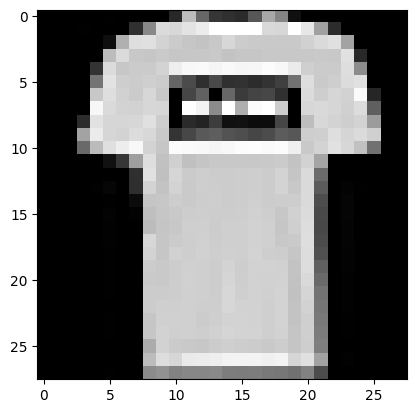

In [ ]:
plt.imshow(x_train[1,],cmap="gray")

In [ ]:
print(x_train[1,])
x_train,x_test=x_train.astype(float)/255,x_test.astype(float)/255
print('--------------------------------------------------------')
print(x_train[1,])

[[  0   0   0   0   0   1   0   0   0   0  41 188 103  54  48  43  87 168
  133  16   0   0   0   0   0   0   0   0]
 [  0   0   0   1   0   0   0  49 136 219 216 228 236 255 255 255 255 217
  215 254 231 160  45   0   0   0   0   0]
 [  0   0   0   0   0  14 176 222 224 212 203 198 196 200 215 204 202 201
  201 201 209 218 224 164   0   0   0   0]
 [  0   0   0   0   0 188 219 200 198 202 198 199 199 201 196 198 198 200
  200 200 200 201 200 225  41   0   0   0]
 [  0   0   0   0  51 219 199 203 203 212 238 248 250 245 249 246 247 252
  248 235 207 203 203 222 140   0   0   0]
 [  0   0   0   0 116 226 206 204 207 204 101  75  47  73  48  50  45  51
   63 113 222 202 206 220 224   0   0   0]
 [  0   0   0   0 200 222 209 203 215 200   0  70  98   0 103  59  68  71
   49   0 219 206 214 210 250  38   0   0]
 [  0   0   0   0 247 218 212 210 215 214   0 254 243 139 255 174 251 255
  205   0 215 217 214 208 220  95   0   0]
 [  0   0   0  45 226 214 214 215 224 205   0  42  35  60  16  1

In [ ]:
model=keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))
model.add(keras.layers.Dense(100,activation="relu"))
model.add(keras.layers.Dense(75,activation="relu"))
model.add(keras.layers.Dense(10,activation="softmax"))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 75)                  │           7,575 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             760 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 86,835 (339.20 KB)

 Trainable params: 86,835 (339.20 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
weights,bias=model.layers[1].get_weights()

In [ ]:
weights.shape

(784, 100)

In [ ]:
bias.shape

(100,)

In [ ]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [ ]:
history=model.fit(x_train,y_train,epochs=50,validation_split=0.15)

Epoch 1/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6239 - loss: 1.1267 - val_accuracy: 0.7871 - val_loss: 0.6004
Epoch 2/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8122 - loss: 0.5395 - val_accuracy: 0.8242 - val_loss: 0.4932
Epoch 3/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8333 - loss: 0.4756 - val_accuracy: 0.8361 - val_loss: 0.4624
Epoch 4/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8478 - loss: 0.4409 - val_accuracy: 0.8428 - val_loss: 0.4501
Epoch 5/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8507 - loss: 0.4213 - val_accuracy: 0.8493 - val_loss: 0.4287
Epoch 6/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8583 - loss: 0.3983 - val_accuracy: 0.8573 - val_loss: 0.4074
Epoch 7/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8613 - loss: 0.3953 - val_accuracy: 0.8523 - val_loss: 0.4150
Epoch 8/50
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8646 - loss: 0.3805 - 

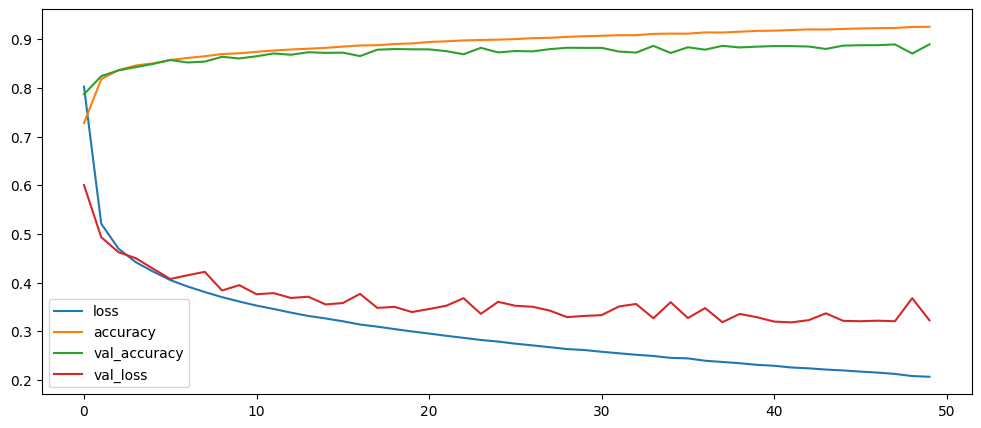

In [ ]:
fig,ax=plt.subplots(figsize=(12,5))
ax.plot(history.history["loss"],label="loss")
ax.plot(history.history["accuracy"],label="accuracy")
ax.plot(history.history["val_accuracy"],label="val_accuracy")
ax.plot(history.history["val_loss"],label="val_loss")
plt.legend()

In [ ]:
def plot_history(history):
  fig,ax=plt.subplots(1,2,figsize=(12,5))
  ax[0].plot(history.history["loss"],label="training loss",color="blue")
  ax[0].plot(history.history["val_loss"],label="validation loss",color="orange")
  ax[0].set_title("loss during training")
  ax[0].set_xlabel("epoch")
  ax[0].set_ylabel("loss")
  ax[0].legend()


  fig,ax=plt.subplots(1,2,figsize=(12,5))
  ax[1].plot(history.history["accuracy"],label="training accuracy",color="blue")
  ax[1].plot(history.history["val_accuracy"],label="validation accuracy",color="orange")
  ax[1].set_title("accuracy during training")
  ax[1].set_xlabel("epoch")
  ax[1].set_ylabel("accuracy")
  ax[1].legend()
  plt.tight_layout()
  plt.show()

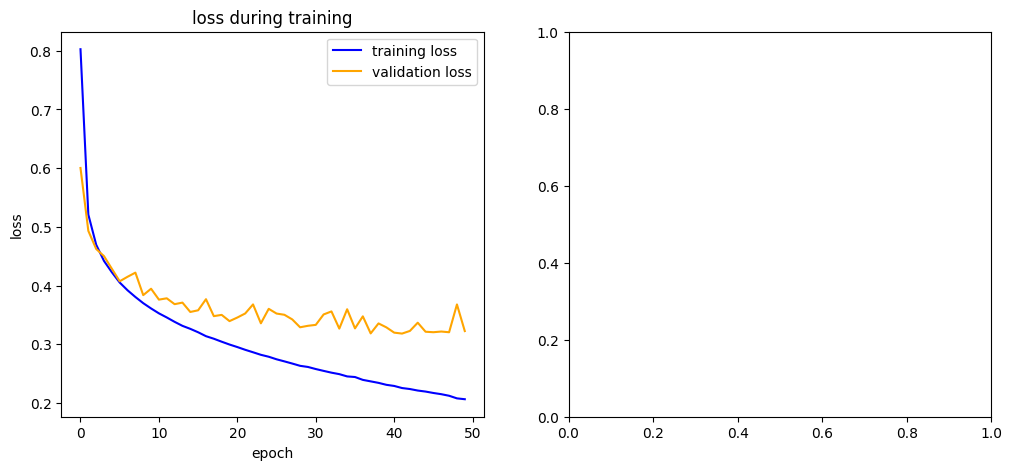

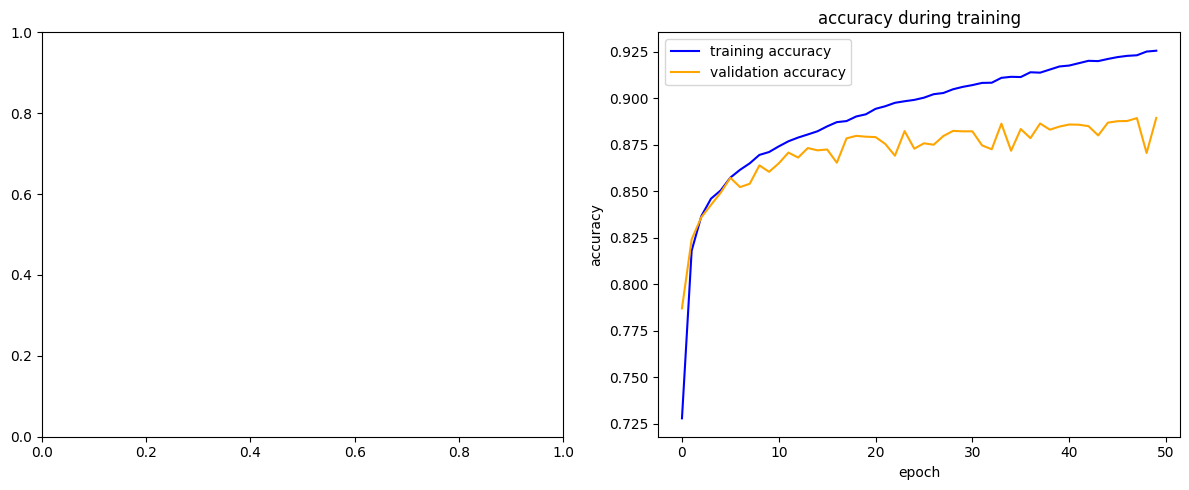

In [ ]:
plot_history(history)

In [ ]:
import numpy as np
x3=x_test[1:3,:,:]
prediction=model.predict(x3).round(2)
predclasses=np.argmax(prediction,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [ ]:
print("predictionclass:", predclasses)
print("Actualclasses:",y_test[1:3])

predictionclass: [2 1]
Actualclasses: [2 1]


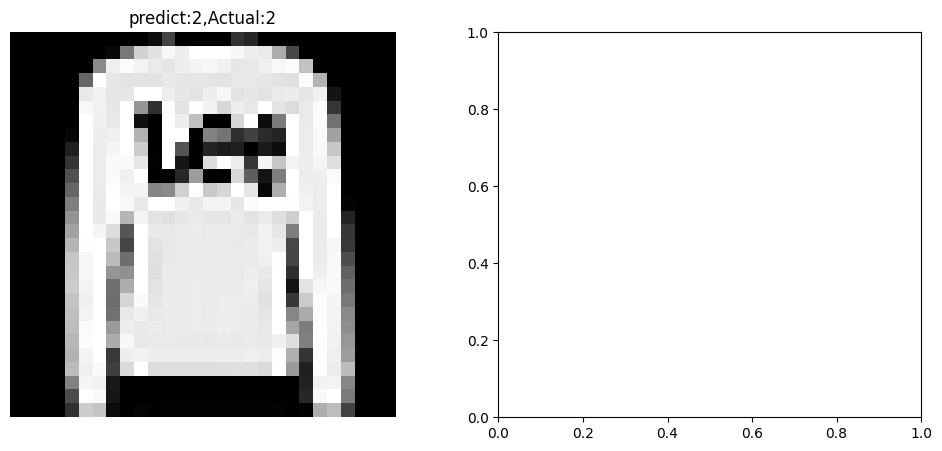

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
for i in range(2):
  ax[i].imshow(x3[i],cmap="gray")
  ax[i].set_title(f"predict:{predclasses[i]},Actual:{y_test[i+1]}")
  ax[i].axis("off")
  plt.show()
